In [ ]:
# ============================================================
# 00 — CONNECT GOOGLE DRIVE / PROJECT
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# ============================================================
# PROJECT PATH
# ============================================================

from pathlib import Path
import sys

PROJECT_DIR = Path(
    "/content/drive/MyDrive/FitnessML_Master"
)

print(f"Project directory: {PROJECT_DIR}")
print(f"Exists: {PROJECT_DIR.exists()}")

Project directory: /content/drive/MyDrive/FitnessML_Master
Exists: True


In [ ]:
# ============================================================
# ADD PROJECT TO PYTHON PATH
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

    import config_fitbit as config
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("=" * 70)
print("FITBIT MODEL INTERPRETABILITY")
print("=" * 70)
print("Project added to Python path.")

FITBIT MODEL INTERPRETABILITY
Project added to Python path.


In [ ]:
# ============================================================
# LOAD MODELING DATASET
# ============================================================

model_path = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "fitbit_modeling_features.csv"
)

model_df = pd.read_csv(model_path)

model_df["ActivityDate"] = pd.to_datetime(
    model_df["ActivityDate"]
)

model_df = (
    model_df
    .sort_values(["ActivityDate", "Id"])
    .reset_index(drop=True)
)

print("=" * 70)
print("MODEL DATASET")
print("=" * 70)

print(f"Shape: {model_df.shape}")
print(f"Users: {model_df['Id'].nunique()}")
print(
    f"Date range: "
    f"{model_df['ActivityDate'].min().date()} → "
    f"{model_df['ActivityDate'].max().date()}"
)

MODEL DATASET
Shape: (680, 68)
Users: 32
Date range: 2016-04-19 → 2016-05-11


In [ ]:
# ============================================================
# FEATURE DEFINITIONS
# ============================================================

target_column = "target_calories_next_day"

base_features = [
    "TotalSteps",
    "TotalDistance",
    "TrackerDistance",
    "LoggedActivitiesDistance",
    "VeryActiveDistance",
    "ModeratelyActiveDistance",
    "LightActiveDistance",
    "SedentaryActiveDistance",
    "VeryActiveMinutes",
    "FairlyActiveMinutes",
    "LightlyActiveMinutes",
    "SedentaryMinutes",
    "Calories"
]

lag_features = [
    c for c in model_df.columns
    if "_lag_" in c
]

rolling_features = [
    c for c in model_df.columns
    if "rolling_" in c
]

all_features = (
    base_features +
    lag_features +
    rolling_features
)

print("=" * 70)
print("FEATURE SET")
print("=" * 70)

print(f"Base features:    {len(base_features)}")
print(f"Lag features:     {len(lag_features)}")
print(f"Rolling features: {len(rolling_features)}")
print(f"All features:     {len(all_features)}")

FEATURE SET
Base features:    13
Lag features:     28
Rolling features: 24
All features:     65


In [ ]:
# ============================================================
# TEMPORAL SPLIT — SAME AS FINAL FOLD FROM 005 / 006
# ============================================================

split_date = pd.Timestamp("2016-05-07")

train = model_df[
    model_df["ActivityDate"] < split_date
].copy()

test = model_df[
    model_df["ActivityDate"] >= split_date
].copy()

X_train = train[all_features]
y_train = train[target_column]

X_test = test[all_features]
y_test = test[target_column]

print("=" * 70)
print("TEMPORAL SPLIT")
print("=" * 70)

print(
    f"Train: {len(train)} rows | "
    f"{train['ActivityDate'].min().date()} → "
    f"{train['ActivityDate'].max().date()}"
)

print(
    f"Test:  {len(test)} rows | "
    f"{test['ActivityDate'].min().date()} → "
    f"{test['ActivityDate'].max().date()}"
)

TEMPORAL SPLIT
Train: 555 rows | 2016-04-19 → 2016-05-06
Test:  125 rows | 2016-05-07 → 2016-05-11


In [ ]:
# ============================================================
# TRAIN BEST MODEL
# ============================================================

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("=" * 70)
print("RANDOM FOREST TRAINED")
print("=" * 70)

print(f"Features: {len(all_features)}")
print(f"Trees:    {rf_model.n_estimators}")

RANDOM FOREST TRAINED
Features: 65
Trees:    200


In [ ]:
# ============================================================
# BUILT-IN FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "feature": all_features,
    "importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 70)

display(
    feature_importance.head(20).round(6)
)

RANDOM FOREST FEATURE IMPORTANCE


,feature,importance
0,Calories_rolling_mean_7,0.511135
1,Calories,0.123969
2,Calories_rolling_mean_3,0.092075
3,Calories_lag_2,0.025871
4,Calories_lag_1,0.015216
5,Calories_lag_7,0.010318
6,LightlyActiveMinutes_lag_1,0.010270
7,SedentaryMinutes_rolling_std_7,0.009367
8,Calories_lag_3,0.008857
9,LightlyActiveMinutes_rolling_std_7,0.007041


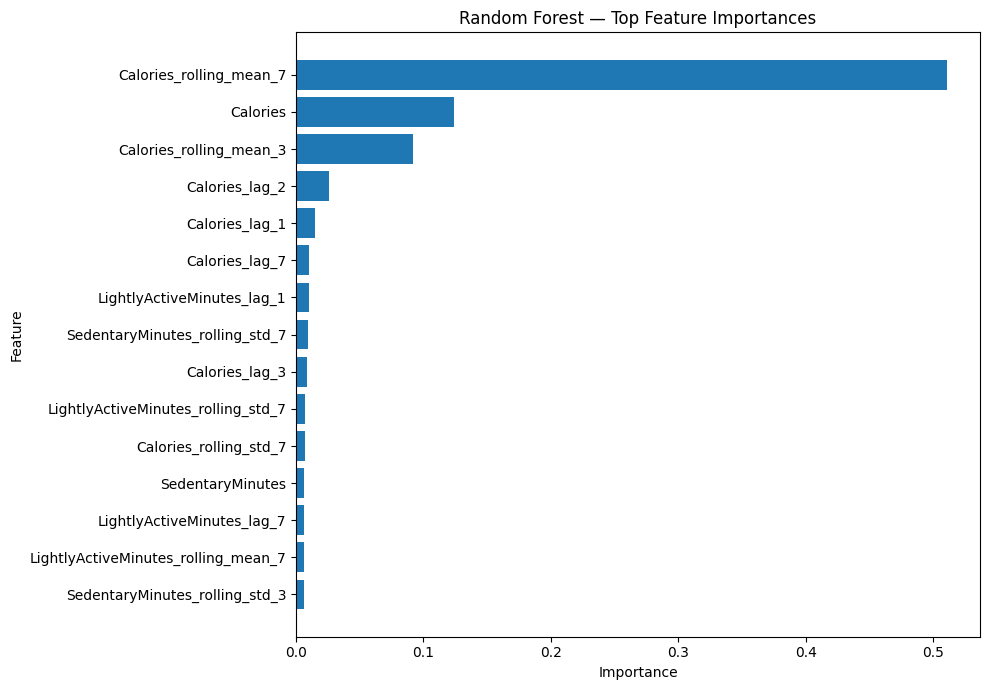

In [ ]:
# ============================================================
# TOP FEATURE IMPORTANCE
# ============================================================

top_n = 15

top_features = (
    feature_importance
    .head(top_n)
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(
    "Random Forest — Top Feature Importances"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PERMUTATION IMPORTANCE
# ============================================================

permutation = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "feature": all_features,
    "importance_mean": permutation.importances_mean,
    "importance_std": permutation.importances_std
})

permutation_df = (
    permutation_df
    .sort_values(
        "importance_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("PERMUTATION IMPORTANCE")
print("=" * 70)

display(
    permutation_df.head(20).round(6)
)

PERMUTATION IMPORTANCE


,feature,importance_mean,importance_std
0,Calories_rolling_mean_7,0.307276,0.024709
1,Calories,0.043521,0.011961
2,LightlyActiveMinutes_lag_1,0.007298,0.004260
3,Calories_lag_1,0.006872,0.007063
4,Calories_lag_7,0.003754,0.003539
5,SedentaryMinutes,0.003259,0.002800
6,Calories_rolling_std_3,0.003032,0.001644
7,FairlyActiveMinutes_lag_7,0.001947,0.001225
8,LightActiveDistance,0.001885,0.001814
9,ModeratelyActiveDistance,0.001675,0.001113


In [ ]:
# ============================================================
# IMPORTANCE COMPARISON
# ============================================================

importance_comparison = (
    feature_importance
    .merge(
        permutation_df,
        on="feature",
        how="inner"
    )
)

importance_comparison["rank_builtin"] = (
    importance_comparison["importance"]
    .rank(
        ascending=False,
        method="min"
    )
)

importance_comparison["rank_permutation"] = (
    importance_comparison["importance_mean"]
    .rank(
        ascending=False,
        method="min"
    )
)

importance_comparison = (
    importance_comparison
    .sort_values("rank_permutation")
)

print("=" * 70)
print("IMPORTANCE COMPARISON")
print("=" * 70)

display(
    importance_comparison.head(20).round(6)
)

IMPORTANCE COMPARISON


,feature,importance,importance_mean,importance_std,rank_builtin,rank_permutation
0,Calories_rolling_mean_7,0.511135,0.307276,0.024709,1.0,1.0
1,Calories,0.123969,0.043521,0.011961,2.0,2.0
6,LightlyActiveMinutes_lag_1,0.010270,0.007298,0.004260,7.0,3.0
4,Calories_lag_1,0.015216,0.006872,0.007063,5.0,4.0
5,Calories_lag_7,0.010318,0.003754,0.003539,6.0,5.0
11,SedentaryMinutes,0.006356,0.003259,0.002800,12.0,6.0
27,Calories_rolling_std_3,0.003748,0.003032,0.001644,28.0,7.0
28,FairlyActiveMinutes_lag_7,0.003708,0.001947,0.001225,29.0,8.0
25,LightActiveDistance,0.004077,0.001885,0.001814,26.0,9.0
45,ModeratelyActiveDistance,0.002766,0.001675,0.001113,46.0,10.0


In [ ]:
# ============================================================
# FEATURE GROUP IMPORTANCE
# ============================================================

def feature_group(feature):

    if feature in base_features:
        return "Base"

    if feature in lag_features:
        return "Lag"

    if feature in rolling_features:
        return "Rolling"

    return "Other"


importance_comparison["group"] = (
    importance_comparison["feature"]
    .apply(feature_group)
)

group_importance = (
    importance_comparison
    .groupby("group")
    .agg(
        features=("feature", "count"),
        builtin_importance=("importance", "sum"),
        permutation_importance=(
            "importance_mean",
            "sum"
        )
    )
    .sort_values(
        "permutation_importance",
        ascending=False
    )
)

print("=" * 70)
print("FEATURE GROUP IMPORTANCE")
print("=" * 70)

display(
    group_importance.round(6)
)

FEATURE GROUP IMPORTANCE


,features,builtin_importance,permutation_importance
group,,,
Rolling,24,0.697805,0.294866
Base,13,0.154307,0.045779
Lag,28,0.147888,-0.016977


005
ML ≈ baseline
        ↓
006
ML signal стабільний, але temporal-dependent
        ↓
007
RF importance ≈ rolling historical calories
        ↓
Висновок
основний predictive signal пов'язаний
із temporal persistence target variable

RF All Features
        vs
RF All Features WITHOUT Calories_rolling_mean_7

In [ ]:
# ============================================================
# DOMINANT FEATURE ABLATION
# ============================================================

dominant_feature = "Calories_rolling_mean_7"

ablation_features = [
    feature
    for feature in all_features
    if feature != dominant_feature
]

print("=" * 70)
print("DOMINANT FEATURE ABLATION")
print("=" * 70)

print(f"Removed feature: {dominant_feature}")
print(f"Full feature set: {len(all_features)}")
print(f"Ablation feature set: {len(ablation_features)}")

DOMINANT FEATURE ABLATION
Removed feature: Calories_rolling_mean_7
Full feature set: 65
Ablation feature set: 64


In [ ]:
# ============================================================
# TRAIN FULL VS ABLATION RANDOM FOREST
# ============================================================

rf_full = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_ablation = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_full.fit(
    train[all_features],
    y_train
)

rf_ablation.fit(
    train[ablation_features],
    y_train
)

pred_full = rf_full.predict(
    test[all_features]
)

pred_ablation = rf_ablation.predict(
    test[ablation_features]
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
# ============================================================
# ABLATION RESULTS
# ============================================================

ablation_results = pd.DataFrame([
    {
        "Model": "Random Forest — All Features",
        "Removed Feature": "None",
        "MAE": mean_absolute_error(
            y_test,
            pred_full
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                pred_full
            )
        ),
        "R2": r2_score(
            y_test,
            pred_full
        )
    },
    {
        "Model": "Random Forest — Ablation",
        "Removed Feature": dominant_feature,
        "MAE": mean_absolute_error(
            y_test,
            pred_ablation
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                pred_ablation
            )
        ),
        "R2": r2_score(
            y_test,
            pred_ablation
        )
    }
])

print("=" * 70)
print("DOMINANT FEATURE ABLATION RESULTS")
print("=" * 70)

display(
    ablation_results.round(4)
)

DOMINANT FEATURE ABLATION RESULTS


,Model,Removed Feature,MAE,RMSE,R2
0,Random Forest — All Features,None,481.7334,740.4334,0.2504
1,Random Forest — Ablation,Calories_rolling_mean_7,484.4384,738.2580,0.2548


In [ ]:
# ============================================================
# ABLATION DELTA
# ============================================================

full_row = ablation_results.iloc[0]
ablation_row = ablation_results.iloc[1]

delta_r2 = (
    ablation_row["R2"]
    - full_row["R2"]
)

delta_mae = (
    ablation_row["MAE"]
    - full_row["MAE"]
)

delta_rmse = (
    ablation_row["RMSE"]
    - full_row["RMSE"]
)

print("=" * 70)
print("ABLATION IMPACT")
print("=" * 70)

print(f"Δ MAE:  {delta_mae:+.4f}")
print(f"Δ RMSE: {delta_rmse:+.4f}")
print(f"Δ R²:   {delta_r2:+.4f}")

ABLATION IMPACT
Δ MAE:  +2.7050
Δ RMSE: -2.1754
Δ R²:   +0.0044


In [ ]:
# ============================================================
# CALORIES HISTORY ABLATION
# ============================================================

calories_features = [
    feature
    for feature in all_features
    if (
        feature == "Calories"
        or feature.startswith("Calories_lag_")
        or feature.startswith("Calories_rolling_")
    )
]

activity_only_features = [
    feature
    for feature in all_features
    if feature not in calories_features
]

print("=" * 70)
print("CALORIES HISTORY ABLATION")
print("=" * 70)

print(f"Calories-history features removed: {len(calories_features)}")
print(f"Remaining activity features:       {len(activity_only_features)}")

print("\nRemoved:")
for feature in calories_features:
    print(f"  - {feature}")

CALORIES HISTORY ABLATION
Calories-history features removed: 9
Remaining activity features:       56

Removed:
  - Calories
  - Calories_lag_1
  - Calories_lag_2
  - Calories_lag_3
  - Calories_lag_7
  - Calories_rolling_mean_3
  - Calories_rolling_std_3
  - Calories_rolling_mean_7
  - Calories_rolling_std_7


In [ ]:
# ============================================================
# TRAIN ACTIVITY-ONLY RANDOM FOREST
# ============================================================

rf_activity_only = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_activity_only.fit(
    train[activity_only_features],
    y_train
)

pred_activity_only = rf_activity_only.predict(
    test[activity_only_features]
)

print("=" * 70)
print("ACTIVITY-ONLY RANDOM FOREST TRAINED")
print("=" * 70)

print(f"Features: {len(activity_only_features)}")

ACTIVITY-ONLY RANDOM FOREST TRAINED
Features: 56


In [ ]:
# ============================================================
# CALORIES HISTORY ABLATION RESULTS
# ============================================================

activity_only_results = pd.DataFrame([
    {
        "Model": "Random Forest — All Features",
        "Features": len(all_features),
        "MAE": mean_absolute_error(
            y_test,
            pred_full
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                pred_full
            )
        ),
        "R2": r2_score(
            y_test,
            pred_full
        )
    },
    {
        "Model": "Random Forest — Activity Only",
        "Features": len(activity_only_features),
        "MAE": mean_absolute_error(
            y_test,
            pred_activity_only
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                pred_activity_only
            )
        ),
        "R2": r2_score(
            y_test,
            pred_activity_only
        )
    }
])

print("=" * 70)
print("CALORIES HISTORY ABLATION RESULTS")
print("=" * 70)

display(
    activity_only_results.round(4)
)

CALORIES HISTORY ABLATION RESULTS


,Model,Features,MAE,RMSE,R2
0,Random Forest — All Features,65,481.7334,740.4334,0.2504
1,Random Forest — Activity Only,56,566.6922,763.6063,0.2027


In [ ]:
# ============================================================
# CALORIES HISTORY ABLATION DELTA
# ============================================================

full_row = activity_only_results.iloc[0]
activity_row = activity_only_results.iloc[1]

delta_mae = (
    activity_row["MAE"]
    - full_row["MAE"]
)

delta_rmse = (
    activity_row["RMSE"]
    - full_row["RMSE"]
)

delta_r2 = (
    activity_row["R2"]
    - full_row["R2"]
)

print("=" * 70)
print("CALORIES HISTORY ABLATION IMPACT")
print("=" * 70)

print(f"Δ MAE:  {delta_mae:+.4f}")
print(f"Δ RMSE: {delta_rmse:+.4f}")
print(f"Δ R²:   {delta_r2:+.4f}")

CALORIES HISTORY ABLATION IMPACT
Δ MAE:  +84.9588
Δ RMSE: +23.1729
Δ R²:   -0.0477


The model relies substantially on recent calorie history, but physical-activity variables retain meaningful predictive information even when all calorie-history features are removed.

In [ ]:
# ============================================================
# 007 — EXPORT AVAILABLE RESULTS
# ============================================================

from pathlib import Path

print("=" * 70)
print("EXPORTING 007 RESULTS")
print("=" * 70)

tables_dir = Path(config.PROJECT_DIR) / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)


def export_if_exists(variable_name, filename):
    """
    Export DataFrame if the variable exists in the notebook.
    """
    if variable_name in globals():
        obj = globals()[variable_name]

        if isinstance(obj, pd.DataFrame):
            obj.to_csv(
                tables_dir / filename,
                index=False
            )
            print(f"✓ {filename}")
            return True

    print(f"- Skipped: {variable_name} not found")
    return False


# ------------------------------------------------------------
# Feature importance results
# ------------------------------------------------------------

export_if_exists(
    "importance_comparison",
    "007_importance_comparison.csv"
)

export_if_exists(
    "feature_group_importance",
    "007_feature_group_importance.csv"
)

export_if_exists(
    "ablation_results",
    "007_ablation_results.csv"
)

export_if_exists(
    "activity_only_results",
    "007_calories_history_ablation.csv"
)


# ------------------------------------------------------------
# Try alternative variable names
# ------------------------------------------------------------

export_if_exists(
    "permutation_importance",
    "007_permutation_importance.csv"
)

export_if_exists(
    "permutation_df",
    "007_permutation_importance.csv"
)

export_if_exists(
    "importance_comparison_df",
    "007_importance_comparison.csv"
)

export_if_exists(
    "feature_group_importance_df",
    "007_feature_group_importance.csv"
)


# ------------------------------------------------------------
# Built-in Random Forest importance
# ------------------------------------------------------------

if "rf_full" in globals() and "all_features" in globals():

    rf_feature_importance = pd.DataFrame({
        "feature": all_features,
        "importance": rf_full.feature_importances_
    }).sort_values(
        "importance",
        ascending=False
    )

    rf_feature_importance.to_csv(
        tables_dir / "007_rf_feature_importance.csv",
        index=False
    )

    print("✓ 007_rf_feature_importance.csv")


# ------------------------------------------------------------
# Final list
# ------------------------------------------------------------

print()
print("=" * 70)
print("EXPORTED 007 FILES")
print("=" * 70)

exported_files = sorted(tables_dir.glob("007_*.csv"))

for path in exported_files:
    print(f"  {path.name}")

print()
print(f"Files exported: {len(exported_files)}")
print(f"Directory: {tables_dir}")

print("=" * 70)
print("007 EXPORT COMPLETE")
print("=" * 70)

EXPORTING 007 RESULTS
✓ 007_importance_comparison.csv
- Skipped: feature_group_importance not found
✓ 007_ablation_results.csv
✓ 007_calories_history_ablation.csv
- Skipped: permutation_importance not found
✓ 007_permutation_importance.csv
- Skipped: importance_comparison_df not found
- Skipped: feature_group_importance_df not found
✓ 007_rf_feature_importance.csv

EXPORTED 007 FILES
  007_ablation_results.csv
  007_calories_history_ablation.csv
  007_importance_comparison.csv
  007_permutation_importance.csv
  007_rf_feature_importance.csv

Files exported: 5
Directory: /content/drive/MyDrive/FitnessML_Master/tables
007 EXPORT COMPLETE


In [26]:
# ============================================================
# RANDOM FOREST PARAMETERS
# ============================================================

print("=" * 70)
print("RANDOM FOREST PARAMETERS")
print("=" * 70)

print(rf_model.get_params())

RANDOM FOREST PARAMETERS
{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 10, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 3, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
